# Data Audit and Quality Control

This notebook performs quality control on the final A1 acoustic dataset and the independent eBird observation dataset before downstream preprocessing, visualization, clustering, and modeling.

The audit separates technically invalid data from unusual but scientifically usable observations. Invalid recordings are removed from downstream analysis, while difficult or unusual recordings are retained and explicitly flagged for later analysis.

## Audit and Cleaning Policy

The audit distinguishes between **data that must be removed** and **data that should be retained but flagged**.

### Remove

A recording is removed from the analysis-ready dataset when:

- the audio file is zero bytes or effectively empty;
- the audio file cannot be decoded or read;
- the recording has zero or near-zero duration;
- the recording has no usable audio URL;
- the recording is otherwise technically invalid for acoustic analysis.

### Flag and Keep

A recording is retained but flagged when:

- the Xeno-canto quality rating is low;
- the recording duration is shorter than approximately 3 seconds;
- the signal amplitude is unusually low;
- clipping is present;
- background noise is audible;
- wind, rain, traffic, or other environmental noise is present;
- multiple species or overlapping vocalizations are present;
- another unusual acoustic condition could affect downstream feature extraction.

Recordings shorter than approximately 3 seconds are specifically flagged because acoustic indices such as ACI, ADI, NDSI, and Bioacoustic Index may be less stable for very short signals. These recordings will therefore be retained for provenance and potential sensitivity analysis rather than automatically removed.

All audit decisions will be documented in a cleaning log containing the recording ID, action, reason, and relevant quality flags.

## Data Sources

The final acoustic dataset consists of 275 Xeno-canto recordings selected during the acquisition stage.

The independent biodiversity reference data consist of eBird observations collected for California, Arizona, and Texas.

The audit will therefore evaluate two related but distinct datasets:

1. **Xeno-canto** — acoustic recordings and associated metadata.
2. **eBird** — independent species observation records used for ecological cross-reference.

The two datasets will not be forced into a one-to-one recording-level join. They represent different forms of ecological evidence and will be compared at appropriate geographic, species, and temporal scales in later analyses.

In [1]:
from pathlib import Path
import json
import os

import pandas as pd
import numpy as np

import librosa
import soundfile as sf

In [2]:
PROJECT_ROOT = Path.cwd().parents[2]

print("Project root:")
print(PROJECT_ROOT)

Project root:
c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity


In [3]:
SELECTED_METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "xenocanto_selected"
)

SELECTED_AUDIO_DIR = (
    PROJECT_ROOT
    / "audio"
    / "validated"
)

EBIRD_RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "ebird"
)

MANIFEST_DIR = (
    PROJECT_ROOT
    / "data"
    / "manifests"
)

FIGURES_RAW_CLEAN_DIR = (
    PROJECT_ROOT
    / "figures"
    / "raw_clean"
)

FIGURES_RAW_CLEAN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Selected metadata:", SELECTED_METADATA_DIR)
print("Selected audio:", SELECTED_AUDIO_DIR)
print("eBird raw data:", EBIRD_RAW_DIR)
print("Manifest directory:", MANIFEST_DIR)
print("Raw/clean figures:", FIGURES_RAW_CLEAN_DIR)

Selected metadata: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\interim\xenocanto_selected
Selected audio: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\audio\validated
eBird raw data: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\raw\ebird
Manifest directory: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\manifests
Raw/clean figures: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\figures\raw_clean


In [4]:
selected_records = {}

for state in ["CA", "AZ", "TX"]:

    path = (
        SELECTED_METADATA_DIR
        / f"xc_a1_selected_{state}.json"
    )

    with open(
        path,
        encoding="utf-8"
    ) as f:

        selected_records[state] = json.load(f)

    print(
        f"{state}: "
        f"{len(selected_records[state])} records loaded"
    )

CA: 100 records loaded
AZ: 75 records loaded
TX: 100 records loaded


In [5]:
audit_rows = []

for state, records in selected_records.items():

    for record in records:

        audit_rows.append({
            "state": state,
            "recording_id": str(record.get("id")),
            "common_name": record.get("en"),
            "scientific_name": (
                f"{record.get('gen', '')} "
                f"{record.get('sp', '')}"
            ).strip(),
            "quality": record.get("q"),
            "date": record.get("date"),
            "time": record.get("time"),
            "latitude": record.get("lat"),
            "longitude": record.get("lon"),
            "duration_metadata": record.get("length"),
            "audio_url": record.get("file"),
            "source_url": record.get("url"),
            "license": record.get("lic"),
        })

audio_audit = pd.DataFrame(audit_rows)

print("Rows:", len(audio_audit))
print("Columns:", len(audio_audit.columns))

Rows: 275
Columns: 13


In [6]:
audio_audit.head()

,state,recording_id,common_name,scientific_name,quality,date,time,latitude,longitude,duration_metadata,audio_url,source_url,license
0,CA,375492,African Collared Dove,Streptopelia roseogrisea,A,2017-06-14,15:00,33.922,-117.2617,0:05,https://xeno-canto.org/375492/download,https://xeno-canto.org/375492,https://creativecommons.org/licenses/by-nc-sa/...
1,CA,952203,Allen's Hummingbird,Selasphorus sasin,A,2024-11-24,08:00,33.6104,-117.7392,0:38,https://xeno-canto.org/952203/download,https://xeno-canto.org/952203,https://creativecommons.org/licenses/by-nc-sa/...
2,CA,452094,American Coot,Fulica americana,A,2018-01-30,12:56,33.2016,-115.597,0:18,https://xeno-canto.org/452094/download,https://xeno-canto.org/452094,https://creativecommons.org/licenses/by-nc-sa/...
3,CA,172887,American Wigeon,Mareca americana,B,2012-03-23,09:54,32.564,-117.1256,0:11,https://xeno-canto.org/172887/download,https://xeno-canto.org/172887,https://creativecommons.org/licenses/by-nc-sa/...
4,CA,449497,Anna's Hummingbird,Calypte anna,A,2018-10-21,07:46,32.686,-117.243,1:50,https://xeno-canto.org/449497/download,https://xeno-canto.org/449497,https://creativecommons.org/licenses/by-nc-sa/...


In [7]:
audio_audit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   state              275 non-null    object
 1   recording_id       275 non-null    object
 2   common_name        275 non-null    object
 3   scientific_name    275 non-null    object
 4   quality            275 non-null    object
 5   date               275 non-null    object
 6   time               275 non-null    object
 7   latitude           275 non-null    object
 8   longitude          275 non-null    object
 9   duration_metadata  275 non-null    object
 10  audio_url          275 non-null    object
 11  source_url         275 non-null    object
 12  license            275 non-null    object
dtypes: object(13)
memory usage: 28.1+ KB


In [8]:
audio_audit.describe(include="all")

,state,recording_id,common_name,scientific_name,quality,date,time,latitude,longitude,duration_metadata,audio_url,source_url,license
count,275,275,275,275,275,275,275,275,275,275,275,275,275
unique,3,275,159,159,2,226,192,204,204,103,275,275,4
top,CA,375492,Black-chinned Hummingbird,Archilochus alexandri,B,1999-04-08,07:00,31.906,-109.1543,0:08,https://xeno-canto.org/375492/download,https://xeno-canto.org/375492,https://creativecommons.org/licenses/by-nc-sa/...
freq,100,1,5,5,189,6,17,16,16,9,1,1,193


In [9]:
print("Total rows:", len(audio_audit))

print(
    "Unique recording IDs:",
    audio_audit["recording_id"].nunique()
)

print(
    "Duplicate recording IDs:",
    audio_audit["recording_id"].duplicated().sum()
)

Total rows: 275
Unique recording IDs: 275
Duplicate recording IDs: 0


In [10]:
print(
    audio_audit["state"]
    .value_counts()
)

state
CA    100
TX    100
AZ     75
Name: count, dtype: int64


In [11]:
audio_files = list(
    SELECTED_AUDIO_DIR.glob("*.mp3")
)

print(f"Audio files found: {len(audio_files)}")

print("\nFirst 20 files:")

for path in audio_files[:20]:
    print(path.name)

Audio files found: 275

First 20 files:
AZ_1035206.mp3
AZ_1080401.mp3
AZ_1080405.mp3
AZ_1101338.mp3
AZ_110689.mp3
AZ_114789.mp3
AZ_132208.mp3
AZ_132209.mp3
AZ_132328.mp3
AZ_132452.mp3
AZ_132684.mp3
AZ_132844.mp3
AZ_132890.mp3
AZ_132942.mp3
AZ_132948.mp3
AZ_132967.mp3
AZ_132968.mp3
AZ_133346.mp3
AZ_133556.mp3
AZ_145955.mp3


In [12]:
audio_audit["audio_filename"] = (
    audio_audit["state"]
    + "_"
    + audio_audit["recording_id"]
    + ".mp3"
)

audio_audit["audio_path"] = (
    audio_audit["audio_filename"]
    .apply(lambda x: SELECTED_AUDIO_DIR / x)
)

audio_audit["file_exists"] = (
    audio_audit["audio_path"]
    .apply(Path.exists)
)

print(
    "Expected audio files:",
    len(audio_audit)
)

print(
    "Files found:",
    audio_audit["file_exists"].sum()
)

print(
    "Files missing:",
    (~audio_audit["file_exists"]).sum()
)

Expected audio files: 275
Files found: 275
Files missing: 0


In [13]:
audio_audit["file_size_bytes"] = (
    audio_audit["audio_path"]
    .apply(lambda p: p.stat().st_size if p.exists() else np.nan)
)

audio_audit["file_size_kb"] = (
    audio_audit["file_size_bytes"] / 1024
)

print(
    audio_audit["file_size_kb"].describe()
)

print(
    "\nZero-byte files:",
    (audio_audit["file_size_bytes"] == 0).sum()
)

count      275.000000
mean      1145.933967
std       2280.886360
min         12.980469
25%        226.140137
50%        434.734375
75%       1165.893555
max      22163.154297
Name: file_size_kb, dtype: float64

Zero-byte files: 0


In [14]:
audio_audit[
    audio_audit["file_size_bytes"] <= 1024
][
    [
        "state",
        "recording_id",
        "audio_filename",
        "file_size_bytes"
    ]
]

,state,recording_id,audio_filename,file_size_bytes


In [15]:
decode_results = []

for _, row in audio_audit.iterrows():

    path = row["audio_path"]

    result = {
        "recording_id": row["recording_id"],
        "state": row["state"],
        "decode_success": False,
        "duration_seconds": np.nan,
        "sample_rate": np.nan,
        "channels": np.nan,
        "rms": np.nan,
        "peak_amplitude": np.nan,
        "clipped": False,
        "decode_error": None,
    }

    try:

        y, sr = librosa.load(
            path,
            sr=None,
            mono=False
        )

        result["decode_success"] = True
        result["sample_rate"] = sr

        if y.ndim == 1:
            result["channels"] = 1
            signal = y

        else:
            result["channels"] = y.shape[0]
            signal = np.mean(y, axis=0)

        result["duration_seconds"] = (
            len(signal) / sr
        )

        result["rms"] = float(
            np.sqrt(np.mean(signal ** 2))
        )

        result["peak_amplitude"] = float(
            np.max(np.abs(signal))
        )

        result["clipped"] = bool(
            np.any(np.abs(signal) >= 0.999)
        )

    except Exception as e:

        result["decode_error"] = str(e)

    decode_results.append(result)

decode_audit = pd.DataFrame(decode_results)

print(
    "Total files:",
    len(decode_audit)
)

print(
    "Successfully decoded:",
    decode_audit["decode_success"].sum()
)

print(
    "Decode failures:",
    (~decode_audit["decode_success"]).sum()
)

Total files: 275
Successfully decoded: 275
Decode failures: 0


In [16]:
audio_audit = audio_audit.merge(
    decode_audit,
    on=["recording_id", "state"],
    how="left"
)

print(audio_audit.shape)

audio_audit.head()

(275, 26)


,state,recording_id,common_name,scientific_name,quality,date,time,latitude,longitude,duration_metadata,...,file_size_bytes,file_size_kb,decode_success,duration_seconds,sample_rate,channels,rms,peak_amplitude,clipped,decode_error
0,CA,375492,African Collared Dove,Streptopelia roseogrisea,A,2017-06-14,15:00,33.922,-117.2617,0:05,...,132062,128.966797,True,5.251678,44100,2,0.010715,0.071781,False,None
1,CA,952203,Allen's Hummingbird,Selasphorus sasin,A,2024-11-24,08:00,33.6104,-117.7392,0:38,...,3709246,3622.310547,True,38.632562,48000,1,0.011445,0.132172,False,None
2,CA,452094,American Coot,Fulica americana,A,2018-01-30,12:56,33.2016,-115.597,0:18,...,308179,300.956055,True,18.960000,48000,1,0.014746,0.704942,False,None
3,CA,172887,American Wigeon,Mareca americana,B,2012-03-23,09:54,32.564,-117.1256,0:11,...,187629,183.231445,True,11.424000,48000,1,0.014006,0.240556,False,None
4,CA,449497,Anna's Hummingbird,Calypte anna,A,2018-10-21,07:46,32.686,-117.243,1:50,...,1768222,1726.779297,True,110.208000,48000,1,0.024224,0.660087,False,None


In [18]:
def duration_to_seconds(value):

    if pd.isna(value):
        return np.nan

    try:
        parts = str(value).split(":")

        if len(parts) == 2:
            minutes = int(parts[0])
            seconds = int(parts[1])

            return minutes * 60 + seconds

        return float(value)

    except Exception:
        return np.nan

In [19]:
audio_audit["duration_metadata_seconds"] = (
    audio_audit["duration_metadata"]
    .apply(duration_to_seconds)
)

audio_audit["duration_difference_seconds"] = (
    audio_audit["duration_seconds"]
    - audio_audit["duration_metadata_seconds"]
)

audio_audit[
    [
        "recording_id",
        "duration_metadata_seconds",
        "duration_seconds",
        "duration_difference_seconds"
    ]
].head(10)

,recording_id,duration_metadata_seconds,duration_seconds,duration_difference_seconds
0,375492,5,5.251678,0.251678
1,952203,38,38.632562,0.632562
2,452094,18,18.960000,0.960000
3,172887,11,11.424000,0.424000
4,449497,110,110.208000,0.208000
5,807038,25,25.680000,0.680000
6,380363,24,24.663220,0.663220
7,691650,0,0.696000,0.696000
8,964245,5,5.166729,0.166729
9,163349,3,3.192000,0.192000


In [20]:
audio_audit["duration_difference_seconds"].describe()

count    275.000000
mean       0.452982
std        0.300460
min       -0.067052
25%        0.184000
50%        0.458186
75%        0.708424
max        0.992000
Name: duration_difference_seconds, dtype: float64

In [21]:
audio_audit["flag_short_duration"] = (
    audio_audit["duration_seconds"] < 3
)

audio_audit["flag_low_amplitude"] = (
    audio_audit["rms"] < 0.01
)

audio_audit["flag_clipping"] = (
    audio_audit["clipped"]
)

audio_audit["flag_low_quality"] = (
    audio_audit["quality"].isin(["C", "D"])
)

audio_audit["flag_any"] = (
    audio_audit[
        [
            "flag_short_duration",
            "flag_low_amplitude",
            "flag_clipping",
            "flag_low_quality"
        ]
    ].any(axis=1)
)

In [22]:
print(
    "Short recordings:",
    audio_audit["flag_short_duration"].sum()
)

print(
    "Low-amplitude recordings:",
    audio_audit["flag_low_amplitude"].sum()
)

print(
    "Clipped recordings:",
    audio_audit["flag_clipping"].sum()
)

print(
    "Low-quality recordings:",
    audio_audit["flag_low_quality"].sum()
)

print(
    "Any flag:",
    audio_audit["flag_any"].sum()
)

Short recordings: 8
Low-amplitude recordings: 53
Clipped recordings: 8
Low-quality recordings: 0
Any flag: 67


In [23]:
audio_audit[
    audio_audit["flag_low_amplitude"]
][
    [
        "state",
        "recording_id",
        "common_name",
        "duration_seconds",
        "rms",
        "peak_amplitude",
        "clipped"
    ]
].sort_values("rms").head(20)

,state,recording_id,common_name,duration_seconds,rms,peak_amplitude,clipped
129,AZ,154199,Montezuma Quail,59.324082,0.000494,0.041651,False
203,TX,731959,Burrowing Owl,30.163917,0.001408,0.026478,False
7,CA,691650,Black-chinned Hummingbird,0.696000,0.001943,0.015527,False
154,AZ,132942,Calliope Hummingbird,6.269388,0.002125,0.051334,False
38,CA,134480,Mexican Whip-poor-will,71.192381,0.002524,0.027934,False
112,AZ,132948,Calliope Hummingbird,33.280000,0.002719,0.053069,False
218,TX,656787,Common Poorwill,2.112000,0.002731,0.050621,False
58,CA,256444,Vaux's Swift,23.032729,0.002875,0.025712,False
159,AZ,623628,Gadwall,22.848000,0.003169,0.122748,False
227,TX,820865,Eastern Screech Owl,167.459917,0.003361,0.035082,False


In [24]:
audio_audit["rms"].describe()

count    275.000000
mean       0.031514
std        0.031598
min        0.000494
25%        0.011218
50%        0.022267
75%        0.040169
max        0.232941
Name: rms, dtype: float64

In [25]:
audio_audit["audit_action"] = "KEEP"

audio_audit.loc[
    (
        ~audio_audit["file_exists"]
        | ~audio_audit["decode_success"]
        | (audio_audit["file_size_bytes"] == 0)
        | audio_audit["duration_seconds"].isna()
        | (audio_audit["duration_seconds"] <= 0)
    ),
    "audit_action"
] = "REMOVE"

audio_audit.loc[
    (
        (audio_audit["audit_action"] == "KEEP")
        & audio_audit["flag_any"]
    ),
    "audit_action"
] = "FLAG"

In [26]:
print(audio_audit["audit_action"].value_counts())

audit_action
KEEP    208
FLAG     67
Name: count, dtype: int64


In [27]:
def get_audit_reason(row):
    reasons = []

    if not row["file_exists"]:
        reasons.append("missing_file")

    if not row["decode_success"]:
        reasons.append("decode_failure")

    if row["file_size_bytes"] == 0:
        reasons.append("zero_byte_file")

    if pd.isna(row["duration_seconds"]):
        reasons.append("missing_duration")
    elif row["duration_seconds"] <= 0:
        reasons.append("invalid_duration")

    if row["flag_short_duration"]:
        reasons.append("short_duration")

    if row["flag_low_amplitude"]:
        reasons.append("low_amplitude")

    if row["flag_clipping"]:
        reasons.append("clipping")

    if row["flag_low_quality"]:
        reasons.append("low_quality")

    if not reasons:
        return "none"

    return ";".join(reasons)


audio_audit["audit_reason"] = (
    audio_audit.apply(get_audit_reason, axis=1)
)

In [28]:
print(audio_audit["audit_reason"].value_counts())

audit_reason
none                            208
low_amplitude                    51
clipping                          8
short_duration                    6
short_duration;low_amplitude      2
Name: count, dtype: int64


In [52]:
cleaning_log = audio_audit[
    [
        "recording_id",
        "state",
        "common_name",
        "scientific_name",
        "audit_action",
        "audit_reason",

        # Individual audit flags
        "flag_short_duration",
        "flag_low_amplitude",
        "flag_clipping",
        "flag_low_quality",
        "flag_any",

        # Measured file/audio properties
        "file_size_bytes",
        "duration_seconds",
        "rms",
        "peak_amplitude",

        # Source metadata quality
        "quality"
    ]
].copy()

In [30]:
cleaning_log_path = (
    MANIFEST_DIR / "cleaning_log.csv"
)

cleaning_log.to_csv(
    cleaning_log_path,
    index=False
)

print("Saved:", cleaning_log_path)

Saved: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\manifests\cleaning_log.csv


In [53]:
cleaning_log_path = (
    MANIFEST_DIR / "cleaning_log.csv"
)

cleaning_log.to_csv(
    cleaning_log_path,
    index=False
)

print("Saved:", cleaning_log_path)
print("Shape:", cleaning_log.shape)
print("\nColumns:")
print(cleaning_log.columns.tolist())

Saved: c:\Users\Samanwita\Downloads\from-soundscapes-to-biodiversity\data\manifests\cleaning_log.csv
Shape: (275, 16)

Columns:
['recording_id', 'state', 'common_name', 'scientific_name', 'audit_action', 'audit_reason', 'flag_short_duration', 'flag_low_amplitude', 'flag_clipping', 'flag_low_quality', 'flag_any', 'file_size_bytes', 'duration_seconds', 'rms', 'peak_amplitude', 'quality']


In [54]:
print("Short duration:",
      cleaning_log["flag_short_duration"].sum())

print("Low amplitude:",
      cleaning_log["flag_low_amplitude"].sum())

print("Clipping:",
      cleaning_log["flag_clipping"].sum())

print("Low quality:",
      cleaning_log["flag_low_quality"].sum())

print("Any flag:",
      cleaning_log["flag_any"].sum())

Short duration: 8
Low amplitude: 53
Clipping: 8
Low quality: 0
Any flag: 67


In [55]:
print("Short duration:", cleaning_log["flag_short_duration"].sum())
print("Low amplitude:", cleaning_log["flag_low_amplitude"].sum())
print("Clipping:", cleaning_log["flag_clipping"].sum())
print("Low quality:", cleaning_log["flag_low_quality"].sum())
print("Any flag:", cleaning_log["flag_any"].sum())

Short duration: 8
Low amplitude: 53
Clipping: 8
Low quality: 0
Any flag: 67


In [31]:
ebird_records = {}

for state in ["CA", "AZ", "TX"]:

    path = (
        EBIRD_RAW_DIR
        / f"ebird_observations_raw_{state}.json"
    )

    with open(path, encoding="utf-8") as f:
        ebird_records[state] = json.load(f)

    print(
        f"{state}: {len(ebird_records[state])} observations"
    )

CA: 495 observations
AZ: 373 observations
TX: 458 observations


In [32]:
ebird_rows = []

for state, observations in ebird_records.items():

    for obs in observations:

        ebird_rows.append({
            "state": state,
            "species_code": obs.get("speciesCode"),
            "common_name": obs.get("comName"),
            "scientific_name": obs.get("sciName"),
            "latitude": obs.get("lat"),
            "longitude": obs.get("lng"),
            "observation_date": obs.get("obsDt"),
            "location_name": obs.get("locName"),
        })

ebird_audit = pd.DataFrame(ebird_rows)

print("Rows:", len(ebird_audit))
print("Columns:", len(ebird_audit.columns))

Rows: 1326
Columns: 8


In [33]:
ebird_audit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1326 entries, 0 to 1325
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   state             1326 non-null   object 
 1   species_code      1326 non-null   object 
 2   common_name       1326 non-null   object 
 3   scientific_name   1326 non-null   object 
 4   latitude          1326 non-null   float64
 5   longitude         1326 non-null   float64
 6   observation_date  1326 non-null   object 
 7   location_name     1326 non-null   object 
dtypes: float64(2), object(6)
memory usage: 83.0+ KB


In [34]:
print("Missing species codes:")
print(ebird_audit["species_code"].isna().sum())

print("\nMissing common names:")
print(ebird_audit["common_name"].isna().sum())

print("\nMissing latitude:")
print(ebird_audit["latitude"].isna().sum())

print("\nMissing longitude:")
print(ebird_audit["longitude"].isna().sum())

print("\nMissing observation dates:")
print(ebird_audit["observation_date"].isna().sum())

Missing species codes:
0

Missing common names:
0

Missing latitude:
0

Missing longitude:
0

Missing observation dates:
0


In [35]:
print(
    "Exact duplicate rows:",
    ebird_audit.duplicated().sum()
)

Exact duplicate rows: 0


In [36]:
ebird_duplicates = ebird_audit.duplicated(
    subset=[
        "state",
        "species_code",
        "latitude",
        "longitude",
        "observation_date"
    ],
    keep=False
)

print(
    "Potential duplicate observations:",
    ebird_duplicates.sum()
)

Potential duplicate observations: 0


In [37]:
STATE_BOUNDS = {
    "CA": {
        "lat_min": 32.5,
        "lat_max": 42.0,
        "lon_min": -124.5,
        "lon_max": -114.1,
    },
    "AZ": {
        "lat_min": 31.3,
        "lat_max": 37.0,
        "lon_min": -114.9,
        "lon_max": -109.0,
    },
    "TX": {
        "lat_min": 25.8,
        "lat_max": 36.5,
        "lon_min": -106.7,
        "lon_max": -93.5,
    },
}

In [39]:
audio_audit["latitude"] = pd.to_numeric(
    audio_audit["latitude"],
    errors="coerce"
)

audio_audit["longitude"] = pd.to_numeric(
    audio_audit["longitude"],
    errors="coerce"
)

print("Latitude dtype:", audio_audit["latitude"].dtype)
print("Longitude dtype:", audio_audit["longitude"].dtype)

print("\nMissing latitude:", audio_audit["latitude"].isna().sum())
print("Missing longitude:", audio_audit["longitude"].isna().sum())

Latitude dtype: float64
Longitude dtype: float64

Missing latitude: 0
Missing longitude: 0


In [40]:
def coordinate_in_state(row):

    if pd.isna(row["latitude"]) or pd.isna(row["longitude"]):
        return False

    bounds = STATE_BOUNDS[row["state"]]

    return (
        bounds["lat_min"] <= row["latitude"] <= bounds["lat_max"]
        and
        bounds["lon_min"] <= row["longitude"] <= bounds["lon_max"]
    )

In [41]:
selected_records = {}

for state in ["CA", "AZ", "TX"]:

    path = (
        SELECTED_METADATA_DIR
        / f"xc_a1_selected_{state}.json"
    )

    with open(
        path,
        encoding="utf-8"
    ) as f:

        selected_records[state] = json.load(f)

    print(
        f"{state}: "
        f"{len(selected_records[state])} records loaded"
    )

CA: 100 records loaded
AZ: 75 records loaded
TX: 100 records loaded


In [43]:
audio_audit["latitude"] = pd.to_numeric(
    audio_audit["latitude"],
    errors="coerce"
)

audio_audit["longitude"] = pd.to_numeric(
    audio_audit["longitude"],
    errors="coerce"
)

print("Latitude dtype:", audio_audit["latitude"].dtype)
print("Longitude dtype:", audio_audit["longitude"].dtype)

print("\nMissing latitude:", audio_audit["latitude"].isna().sum())
print("Missing longitude:", audio_audit["longitude"].isna().sum())

Latitude dtype: float64
Longitude dtype: float64

Missing latitude: 0
Missing longitude: 0


In [44]:
STATE_BOUNDS = {
    "CA": {
        "lat_min": 32.5,
        "lat_max": 42.0,
        "lon_min": -124.5,
        "lon_max": -114.1,
    },
    "AZ": {
        "lat_min": 31.3,
        "lat_max": 37.0,
        "lon_min": -114.9,
        "lon_max": -109.0,
    },
    "TX": {
        "lat_min": 25.8,
        "lat_max": 36.5,
        "lon_min": -106.7,
        "lon_max": -93.5,
    },
}


def coordinate_in_state(row):

    if pd.isna(row["latitude"]) or pd.isna(row["longitude"]):
        return False

    bounds = STATE_BOUNDS[row["state"]]

    return (
        bounds["lat_min"] <= row["latitude"] <= bounds["lat_max"]
        and
        bounds["lon_min"] <= row["longitude"] <= bounds["lon_max"]
    )


audio_audit["coordinates_in_assigned_box"] = (
    audio_audit.apply(
        coordinate_in_state,
        axis=1
    )
)

print(
    audio_audit["coordinates_in_assigned_box"]
    .value_counts()
)

coordinates_in_assigned_box
True    275
Name: count, dtype: int64


In [45]:
outside_box = audio_audit[
    ~audio_audit["coordinates_in_assigned_box"]
]

print(
    "Records outside assigned bounding box:",
    len(outside_box)
)

outside_box[
    [
        "recording_id",
        "state",
        "common_name",
        "latitude",
        "longitude"
    ]
]

Records outside assigned bounding box: 0


,recording_id,state,common_name,latitude,longitude


## Final Audit Summary

The final A1 acoustic dataset contains 275 unique Xeno-canto recordings across California, Arizona, and Texas. All selected recordings were successfully located and decoded, and no recordings met the criteria for technical removal.

A total of 67 recordings were flagged for potentially challenging acoustic characteristics, including low amplitude, clipping, or short duration. These recordings were retained because unusual acoustic conditions may contain scientifically relevant information and can be investigated in later robustness and signal-enhancement experiments.

The independent eBird dataset contains 1,326 observations. No missing species identifiers, geographic coordinates, observation dates, exact duplicates, or potential species-location-date duplicates were detected during the audit.

Finally, all 275 Xeno-canto recordings fall within the geographic bounding boxes used during acquisition. The resulting datasets are therefore suitable for downstream cleaning, acoustic feature extraction, exploratory analysis, and subsequent machine-learning experiments.

In [46]:
audit_summary = pd.DataFrame({
    "Metric": [
        "Total Xeno-canto recordings",
        "Unique recording IDs",
        "Technical removals",
        "Flagged recordings",
        "Unflagged recordings",
        "eBird observations",
        "Missing eBird species codes",
        "Missing eBird coordinates",
        "Exact eBird duplicates",
        "Records outside geographic bounding box"
    ],
    "Value": [
        len(audio_audit),
        audio_audit["recording_id"].nunique(),
        (audio_audit["audit_action"] == "REMOVE").sum(),
        (audio_audit["audit_action"] == "FLAG").sum(),
        (audio_audit["audit_action"] == "KEEP").sum(),
        len(ebird_audit),
        ebird_audit["species_code"].isna().sum(),
        (
            ebird_audit["latitude"].isna()
            | ebird_audit["longitude"].isna()
        ).sum(),
        ebird_audit.duplicated().sum(),
        (~audio_audit["coordinates_in_assigned_box"]).sum()
    ]
})

audit_summary

,Metric,Value
0,Total Xeno-canto recordings,275
1,Unique recording IDs,275
2,Technical removals,0
3,Flagged recordings,67
4,Unflagged recordings,208
5,eBird observations,1326
6,Missing eBird species codes,0
7,Missing eBird coordinates,0
8,Exact eBird duplicates,0
9,Records outside geographic bounding box,0


In [49]:
print(
    audit_summary.to_string(index=False)
)

                                 Metric  Value
            Total Xeno-canto recordings    275
                   Unique recording IDs    275
                     Technical removals      0
                     Flagged recordings     67
                   Unflagged recordings    208
                     eBird observations   1326
            Missing eBird species codes      0
              Missing eBird coordinates      0
                 Exact eBird duplicates      0
Records outside geographic bounding box      0


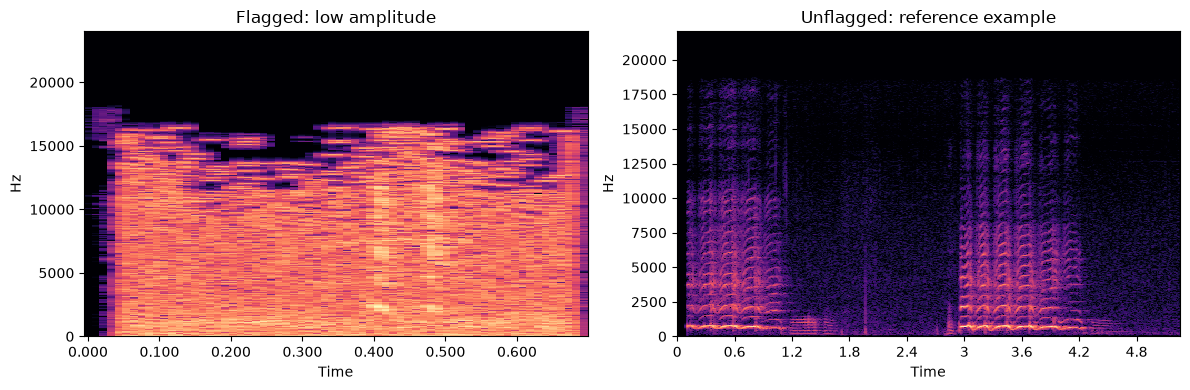

<Figure size 640x480 with 0 Axes>

In [51]:
import matplotlib.pyplot as plt
import librosa.display

flagged_example = audio_audit.loc[audio_audit["flag_low_amplitude"], "audio_path"].iloc[0]
clean_example = audio_audit.loc[audio_audit["audit_action"] == "KEEP", "audio_path"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, path, title in zip(axes, [flagged_example, clean_example], ["Flagged: low amplitude", "Unflagged: reference example"]):
    y, sr = librosa.load(path, sr=None)
    S = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(S, sr=sr, x_axis="time", y_axis="hz", ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "raw_clean" / "raw_vs_clean_example.png", dpi=150)
plt.show()
plt.savefig(
    PROJECT_ROOT
    / "figures"
    / "raw_clean"
    / "flagged_vs_unflagged_example.png",
    dpi=200,
    bbox_inches="tight"
)

### Example of Flagged and Unflagged Recordings

The left spectrogram shows a recording flagged for unusually low amplitude. Despite its lower overall signal level, the recording contains visible spectral and temporal structure and is therefore retained rather than removed. The right panel shows an unflagged recording with clearly visible acoustic structure. The comparison illustrates the audit policy of distinguishing technically invalid recordings from acoustically challenging but potentially informative observations.